In [2]:
from misc import *
import constant

# upto 5 long track candidates isMuon
LTRACK5_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/isMuon_Tr1_5_B2JpsiK_PbPb/LeadLead_B2JpsiKTuple_all.root"
DEFAULT_TREE_NAME = "B2JpsiKTuple/DecayTree"

df = load_root(LTRACK5_FILE_PATH, DEFAULT_TREE_NAME)
df = df[df["Kplus_isMuon"] == False]
df = df[(constant.JPSI_MASS-65 <= df["J_psi_1S_M"]) & (df["J_psi_1S_M"] <= constant.JPSI_MASS+65)]

In [3]:

# df, _ = filter_duplicates_by_performance(df, "Bplus_ENDVERTEX_CHI2", "min")
# df, _ = filter_duplicates_by_performance(df, "Kplus_PIDK", "max")

# df = df[df["Bplus_ENDVERTEX_CHI2"]/df["Bplus_ENDVERTEX_NDOF"] < 1]
# df = df[df["Kplus_PIDK"] > 0]

df = df[df["nVeloTracks"] >= 7]

# df = df[df["log_hrc_fom"] < 11.5]

print(len(df))


5645


In [4]:
import zfit
import zfit.plot
import matplotlib.pyplot as plt
import scipy

/software/ai21208/Code/venv/lib/python3.12/site-packages/zfit/__init__.py:60: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(
2025-03-19 12:30:05.824134: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742387405.840216 1904244 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742387405.846044 1904244 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [7]:
bounds = (4500, 6000)

# Define the observable (entire range of the data)
obs = zfit.Space("m", limits=bounds)

data_np = df["Bplus_M"].to_numpy()
data_np = data_np[(data_np > bounds[0]) & (data_np < bounds[1])]

print(f"{len(data_np)=}")

data = zfit.Data.from_numpy(array=data_np, obs=obs)

mu = zfit.param.ConstantParameter("mu", constant.BPLUS_MASS) # fix gaussian mean

sigma = 23

sigma = zfit.Parameter("sigma", sigma, floating=False) # fixed sigma

lambda_ = zfit.Parameter("lambda", -0.001)

# calculate a crude upper limit for Nsig for parameter bounds
full_pm_20MeV_yield = len(df[(df["Bplus_M"] < constant.BPLUS_MASS + 20) & (df["Bplus_M"] > constant.BPLUS_MASS - 20)])

# Define the yields (Nsig and Nbkg)
Nsig = zfit.Parameter("Nsig", 0)  # Floating signal yield
Nbkg = zfit.Parameter("Nbkg", 300)  # Floating background yield

signal = zfit.pdf.Gauss(mu=mu, sigma=sigma, obs=obs).create_extended(Nsig)
background = zfit.pdf.Exponential(lam=lambda_, obs=obs).create_extended(Nbkg)

total = zfit.pdf.SumPDF([signal, background])

nll = zfit.loss.ExtendedUnbinnedNLL(model=total, data=data)

minimizer = zfit.minimize.Minuit()
minimum = minimizer.minimize(nll)
minimum.hesse()
minimum.errors()

print(minimum)

len(data_np)=929
FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_4, Composed_autoparam_5]] data=[<zfit.Data: Data obs=('m',) shape=(929, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00016 │          6587.42 |  9556.321 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)        hesse               errors    at limit
------  ------------------  -----------  -------------------  ----------
Nsig               1.60256  +/-     6.4  -      6   +    6.9       False
Nbkg               927.486  +/-      31  -     31   +     31       False
lambda     

nan
nan
nan
nan
6621.352539673325
6613.897834480625
6609.324403192584
6605.9331762510765
6603.240765555029
6601.023198164574
6599.154363410252
6597.554905152941
6596.171096823507
6594.964610813875
6593.907004556858
6592.976508120363
6592.156037831577
6591.431908653218
6590.792966815224
6590.229986571011
6589.735239158922
6589.302177590003
6588.925201455662
6588.599478320734
6588.320805957528
6588.08550459642
6587.890331597038
6587.732413111508
6587.609188795673
6587.518366659784
6587.4578858847335
6587.425885958526
6587.420680873787
6587.440737412346
6587.484656756296
6587.5511588263125
6587.639068870996
6587.747305926131
6587.874872836309
6588.020847589349
6588.184375759472
6588.364663891594
6588.560973688059
6588.772616882665
6588.998950705724
6589.239373859412
6589.493322935329
6589.7602692166165
6590.039715815675
6590.331195105615
6590.634266409661
6590.948513917702
6591.2735448034655
6591.608987519275
6591.954490248536
6592.30971949854
6592.674358818407
6593.048107628984
6593.4306

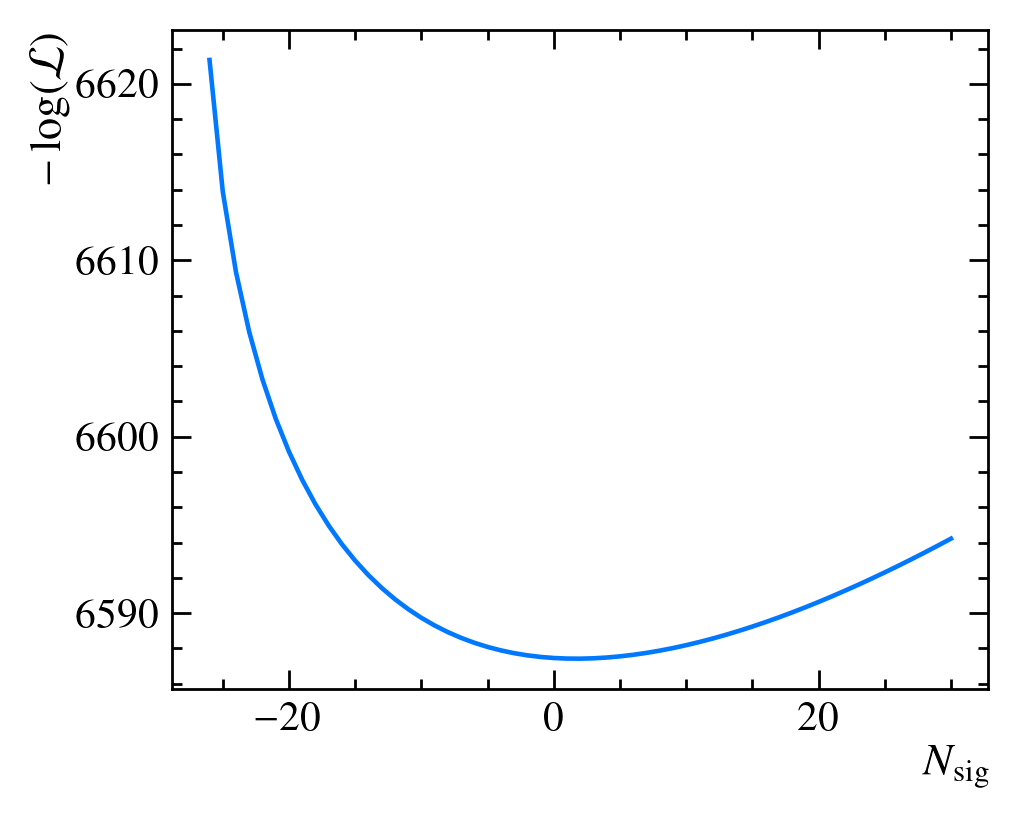

In [ ]:
plt.figure(figsize=(5*2,4*2))


test_points = np.linspace(-30, 30, 61)
nll_vals = []
for point in test_points:
    Nsig.set_value(point)
    nll_vals.append(nll.value().numpy())

print("\n".join([f"{val}" for val in nll_vals]))
    
# Plot to visualize
plt.plot(test_points, nll_vals)
plt.xlabel(r'$N_{\mathrm{sig}}$')
plt.ylabel(r'$-\log(\mathcal{L})$')

plt.savefig("figures/Report/Bplus_NLL.svg")

In [ ]:
def find_upper_limit(
    nll: zfit.loss.ExtendedUnbinnedNLL,
    Nsig: zfit.Parameter,
    minimum: zfit.result.FitResult,
    ndof=1,
    alpha=0.05, # CL = 1 - alpha
):
    def nll_from_Nsig(
        x: float, nll: zfit.loss.ExtendedUnbinnedNLL, Nsig: zfit.Parameter
    ):
        Nsig.set_value(x)
        return nll.value().numpy()

    nll_Nsig_hat = minimum.fmin  # i.e. minimum of nll
    Nsig_hat = float(minimum.params[Nsig]["value"])

    target_nll = scipy.stats.chi2.isf(alpha, ndof) / 2 + nll_Nsig_hat

    ul_Nsig: scipy.optimize.OptimizeResult = scipy.optimize.minimize_scalar(
        lambda x: abs(target_nll - nll_from_Nsig(x, nll, Nsig)),
        bounds=(Nsig_hat, float(Nsig.upper)),
    )

    return ul_Nsig.x

# print(f"Upper limit for signal yield Nsig: {find_upper_limit(nll, Nsig, minimum)} at 95% CL using a chi-squared distribution")

minimum.errors()



print(f"{minimum.params}")

AttributeError: 'FitResult' object has no attribute 'compute_errors'

In [ ]:
import scipy.integrate


points = np.linspace(0, full_pm_20MeV_yield, 10_000)
likelihoods = []
for point in points:
    Nsig.set_value(point)
    likelihoods.append(nll.value().numpy())

likelihoods = np.array(likelihoods)

likelihoods -= likelihoods.min()

# norm = scipy.integrate.simpson(likelihoods, dx = full_pm_20MeV_yield/3000)
def find_first_95_percent(pdf):
   cumsum = np.cumsum(pdf) / np.sum(pdf)
   upper_index = np.argmax(cumsum >= 0.95)
   return upper_index

ul_index = find_first_95_percent(np.exp(-likelihoods))

Upper limit 14.648


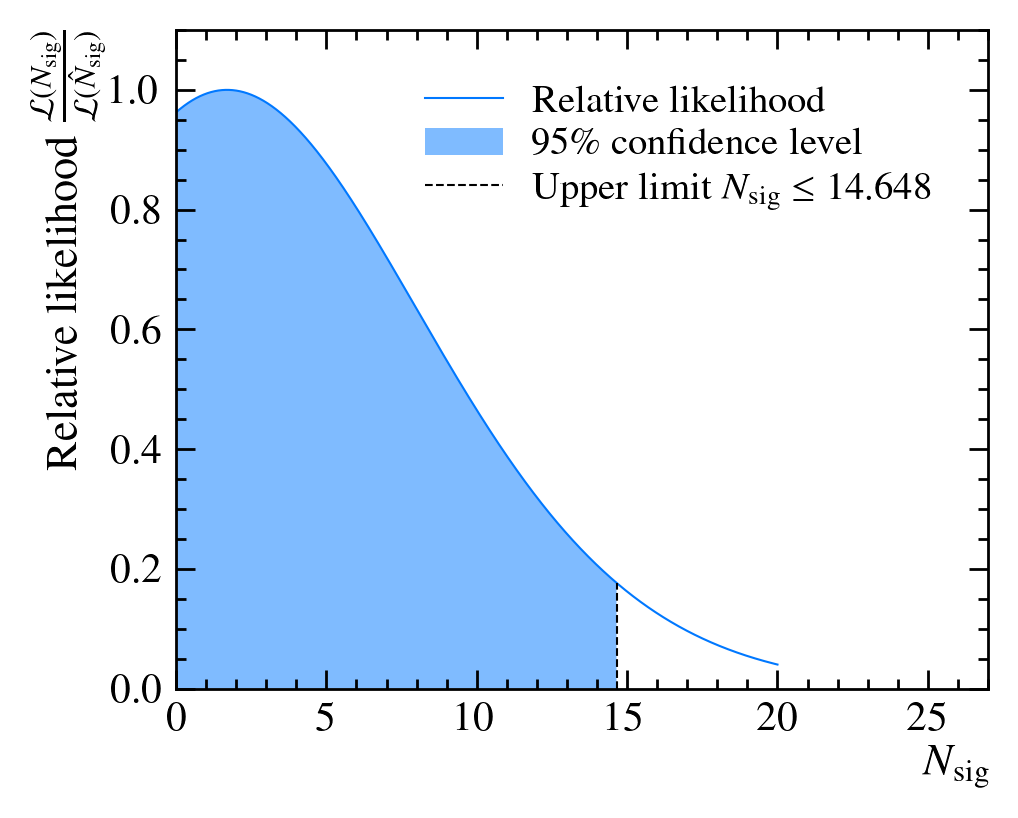

In [ ]:
fig, ax = plt.subplots(figsize=(5*2,4*2))

ax.plot(points, np.exp(-likelihoods), label="Relative likelihood", linewidth=1.5)
ax.set(
    xlabel=r"$N_{\mathrm{sig}}$",
    ylabel=r"Relative likelihood $\frac{\mathcal{L}(N_{\mathrm{sig}})}{\mathcal{L}(\hat{N}_{\mathrm{sig}})}$",
)

ax.fill_between(
    points[:ul_index], np.exp(-likelihoods)[:ul_index], alpha=0.5, label=r"$95\%$ confidence level"
)

ax.plot(
    [points[:ul_index][-1]] * 2,
    [0, np.exp(-likelihoods)[:ul_index][-1]],
    color="k",
    linestyle="--",
    linewidth=1.5,
    label=fr"Upper limit $N_{{\mathrm{{sig}}}} \leq {ul_index * full_pm_20MeV_yield/10_000}$",
)

ax.set(xlim=[0,27], ylim=[0,1.1])

ax.legend()

print(f"Upper limit {ul_index * full_pm_20MeV_yield/10_000}")

fig.savefig("figures/Report/Bplus_ul.svg")

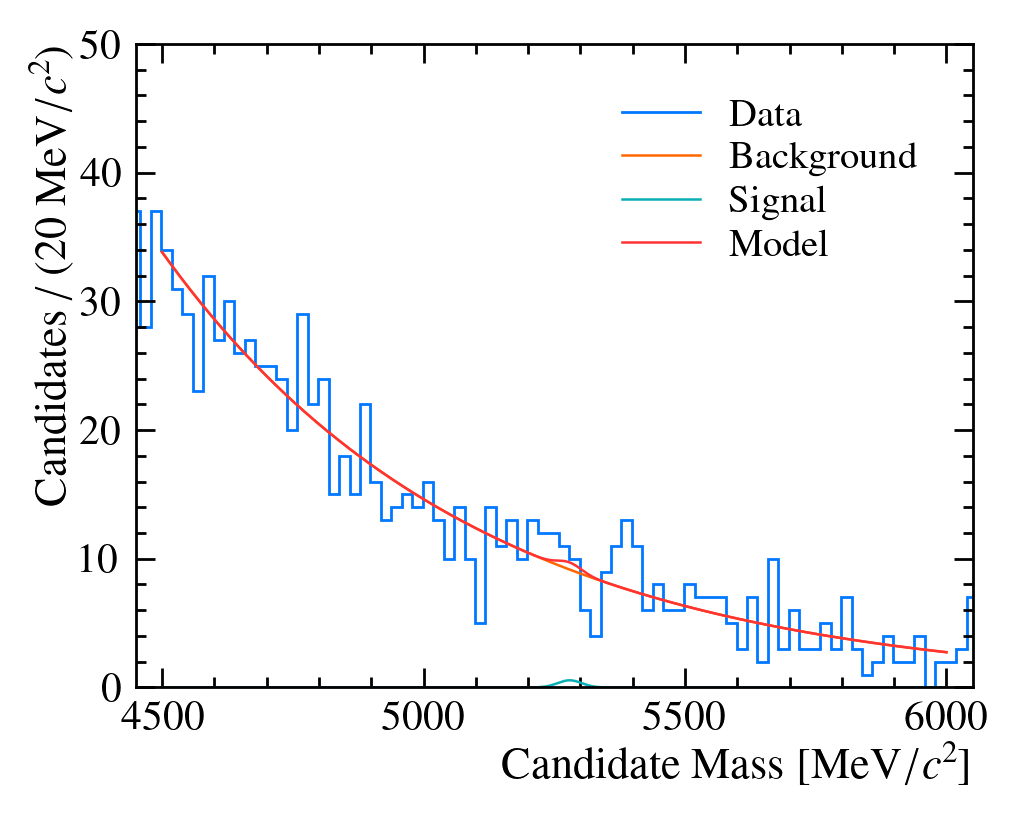

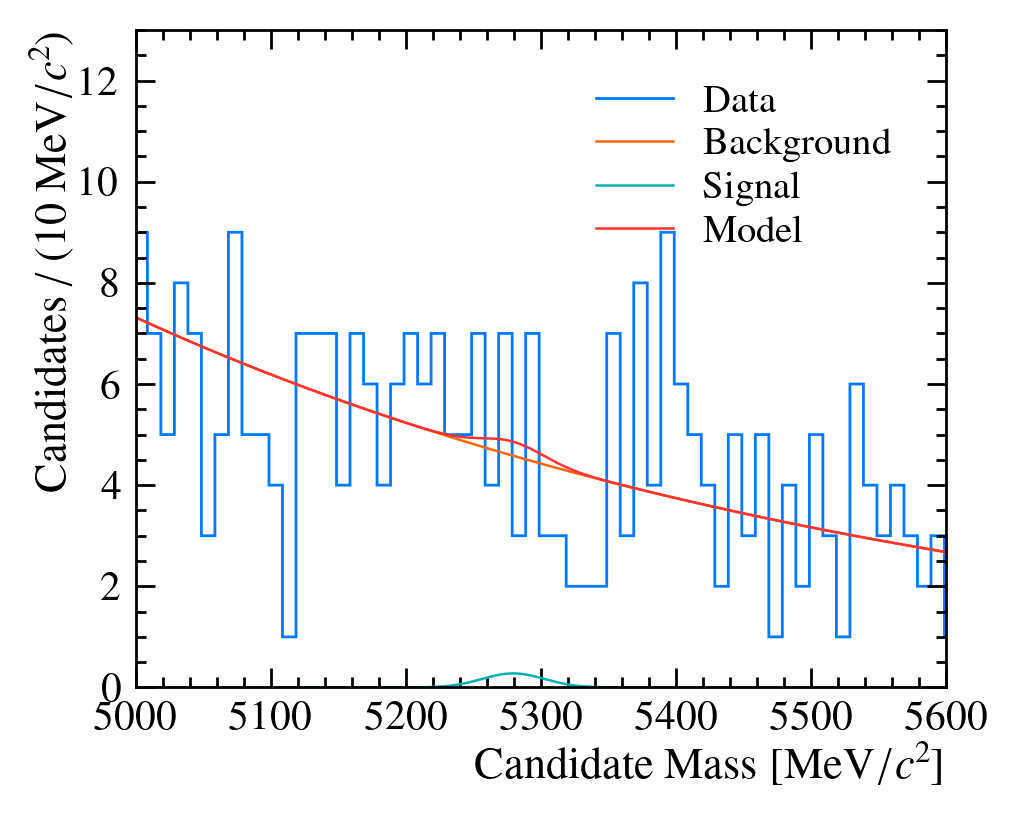

In [ ]:
Nsig.set_value(minimum.params["Nsig"]["value"])
Nbkg.set_value(minimum.params["Nbkg"]["value"])
lambda_.set_value(minimum.params["lambda"]["value"])



bin_width = 20

fig1, ax1 = plt.subplots(figsize=(5*2,4*2))

histogram_ax(
    [p := HistogramPlot(df["Bplus_M"], "Data", bins=bin_width)],
    ax=ax1,
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Candidate Mass",
    xlim=[bounds[0]-50, bounds[1]+50],
    ylim=[0,50]
)

x = np.linspace(*bounds, 500)
ax1.plot(x, background.ext_pdf(x)*bin_width, label="Background", linewidth=1.8)
ax1.plot(x, signal.ext_pdf(x)*bin_width, label="Signal", linewidth=1.8)
ax1.plot(x, total.ext_pdf(x)*bin_width, label="Model", linewidth=1.8)
ax1.legend()

bin_width = 10

fig2, ax2 = plt.subplots(figsize=(5*2,4*2))

figure_bounds = (5000, 5600)

histogram_ax(
    [p := HistogramPlot(df["Bplus_M"], "Data", bins=bin_width)],
    ax=ax2,
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Candidate Mass",
    xlim=figure_bounds,
    ylim=[0,13]
)

x = np.linspace(*figure_bounds, 500)
ax2.plot(x, background.ext_pdf(x)*bin_width, label="Background", linewidth=1.8)
ax2.plot(x, signal.ext_pdf(x)*bin_width, label="Signal", linewidth=1.8)
ax2.plot(x, total.ext_pdf(x)*bin_width, label="Model", linewidth=1.8)
ax2.legend()

fig1.savefig("figures/Report/fit_fullrange.svg")
fig2.savefig("figures/Report/fit_close.svg")

In [ ]:
# from hepstats.hypotests.calculators import FrequentistCalculator, AsymptoticCalculator
# from hepstats.hypotests import UpperLimit
# from hepstats.hypotests.parameters import POI, POIarray

# calculator = AsymptoticCalculator(nll, zfit.minimize.Minuit())
# poinull = POIarray(Nsig, np.linspace(0, full_pm_20MeV_yield, 100))
# poialt = POI(Nsig, 1)

# ul = UpperLimit(calculator, poinull, poialt)
# ul.upperlimit(alpha=0.05)